# Data Analytics — Video Game Sales EDA

**Dataset:** [Video Game Sales — Kaggle](https://www.kaggle.com/datasets/gregorut/videogamesales)

---

## Objective

This analysis examines a global video game sales dataset to understand how performance varies across regions, genres, and time periods. The video game industry presents a compelling case study in regional market dynamics — consumer preferences in North America, Europe, and Japan diverge significantly, and those differences have direct implications for product strategy and regional marketing allocation. The goal is to clean the raw data thoroughly, remove noise introduced by duplicates and outliers, and then surface regional and genre-level patterns through structured visualization and correlation analysis.

## Data

The dataset was sourced from Kaggle and contains records for over 16,000 video game titles before cleaning. Each entry captures the game's title, platform, genre, year of release, and sales figures broken out across four regions: North America (NA_Sales), Europe (EU_Sales), Japan (JP_Sales), and other international markets (Other_Sales), along with a Global_Sales total expressed in millions of units. The Name and Platform columns are dropped early in the analysis as they are not relevant to the regional and genre-level aggregations that follow. After deduplication and outlier removal the working dataset contains approximately 10,000 titles.

In [1]:
#Change directory
%cd /content/drive/MyDrive/Projects/Analytics/Sales

[Errno 2] No such file or directory: '/content/drive/MyDrive/Projects/Analytics/Sales'
/home/runner/work/analytics-projects/analytics-projects/video-game-sales


Below are the libraries that are used in order to perform EDA (Exploratory data analysis) in this work sample.

In [2]:
#Import needed libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set(color_codes=True)

Loading the data into the pandas data frame is certainly one of the most important steps in EDA, as we can see that the value from the data set is comma-separated. So all we have to do is to just read the CSV into a data frame and pandas data frame does the job for us.

To get or load the dataset into the notebook, all I did was one trivial step. In Google Colab at the left-hand side of the notebook, you will find a > (greater than symbol). When you click that you will find a tab with three options, you just have to select Files. Then you can easily upload your file with the help of the Upload option. No need to mount to the google drive or use any specific libraries just upload the data set and your job is done. One thing to remember in this step is that uploaded files will get deleted when this runtime is recycled. This is how I got the data set into the notebook.

In [3]:
#Load the data
vgame_df = pd.read_csv('vgsales.csv')
vgame_df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


#Check the data types
Here we check for the datatypes.

In [4]:
vgame_df.dtypes

Rank              int64
Name                str
Platform            str
Year            float64
Genre               str
Publisher           str
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object

#Dropping irrelevant columns
This step is needed in every EDA because sometimes there would be many columns that we never use in such cases dropping is the only solution. In this case, the columns such as Platform and Name doesn't make any sense to me so I just dropped for this instance.

In [5]:
# Check if 'Name' and 'Genre' columns exist before dropping
if 'Name' in vgame_df.columns and 'Platform' in vgame_df.columns:
    vgame_df.drop(['Name', 'Platform'], axis=1, inplace=True)
    vgame_df.head(5)
else:
    print("Columns 'Name' and/or 'Platform' have already been dropped.")

#Renaming the columns
In this instance, most of the column names are very confusing to read, so I just tweaked their column names. This is a good approach it improves the readability of the data set.

In [6]:
vgame_df = vgame_df.rename(columns={'NA_Sales': 'NA_Sales',
                                    'EU_Sales': 'EU_Sales',
                                    'JP_Sales': 'JP_Sales',
                                    'Other_Sales': 'Other_Sales',
                                    'Global_Sales': 'Global_Sales'})
vgame_df.head(5)

,Rank,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


#Dropping the duplicate rows
This is often a handy thing to do because a data set usually contains more than 10,000 rows and often have some duplicate data which might be disturbing, in this case we only have 5 rows, so here I remove all the duplicate value from the data-set.

For example prior to removing I had 11914 rows of data but after removing the duplicates 10925 data meaning that I had 989 of duplicate data.

In [7]:
vgame_df.shape

(16598, 9)

In [8]:
duplicate_rows_df = vgame_df[vgame_df.duplicated()]
print("number of duplicate rows: ", duplicate_rows_df.shape)

number of duplicate rows:  (0, 9)


Now let us remove the duplicate data because it's ok to remove them.

In [9]:
vgame_df.count()

Rank            16598
Year            16327
Genre           16598
Publisher       16540
NA_Sales        16598
EU_Sales        16598
JP_Sales        16598
Other_Sales     16598
Global_Sales    16598
dtype: int64

So seen above there are 11914 rows and we are removing 989 rows of duplicate data.

In [10]:
vgame_df = vgame_df.drop_duplicates()
vgame_df.head(5)

,Rank,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [11]:
vgame_df.count()

Rank            16598
Year            16327
Genre           16598
Publisher       16540
NA_Sales        16598
EU_Sales        16598
JP_Sales        16598
Other_Sales     16598
Global_Sales    16598
dtype: int64

#Dropping missing or null values
This is mostly similar to the previous step but in here all the missing values are detected and are dropped later. Now, this is not a good approach to do so, because many people just replace the missing values with the mean or the average of that column, but in this case, I just dropped that missing values. This is because there is nearly 100 missing value compared to 10, 000 values this is a small number and this is negligible so I just dropped those values.

In [12]:
print(vgame_df.isnull().sum())

Rank              0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64


After removing null values we confirm all remaining rows are complete across regional and global sales columns.

In [13]:
vgame_df = vgame_df.dropna()    # Dropping the missing values.
vgame_df.count()

Rank            16291
Year            16291
Genre           16291
Publisher       16291
NA_Sales        16291
EU_Sales        16291
JP_Sales        16291
Other_Sales     16291
Global_Sales    16291
dtype: int64

Null values have been removed. The dataset is now clean for analysis.

In [14]:
print(vgame_df.isnull().sum())   # After dropping the values

Rank            0
Year            0
Genre           0
Publisher       0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64


#Detecting Outliers
An outlier is a point or set of points that are different from other points. Sometimes they can be very high or very low. It's often a good idea to detect and remove the outliers. Because outliers are one of the primary reasons for resulting in a less accurate model. Hence it's a good idea to remove them. The outlier detection and removing that I am going to perform is called IQR score technique. Often outliers can be seen with visualizations using a box plot. Shown below are the box plot of MSRP, Cylinders, Horsepower and EngineSize. Herein all the plots, you can find some points are outside the box they are none other than outliers. The technique of finding and removing outlier that I am performing in this assignment is taken help of a tutorial from[ towards data science](https://towardsdatascience.com/ways-to-detect-and-remove-the-outliers-404d16608dba).

<Axes: xlabel='NA_Sales'>

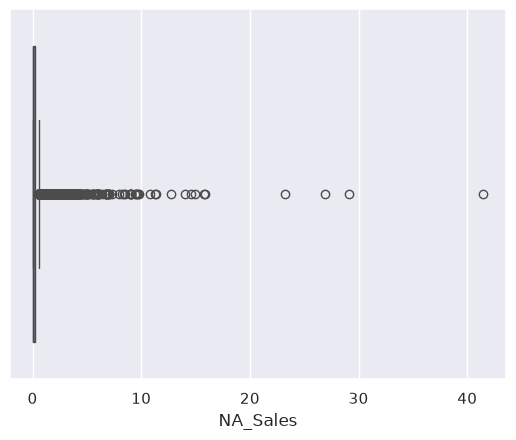

In [15]:
sns.boxplot(x=vgame_df['NA_Sales'])

<Axes: xlabel='EU_Sales'>

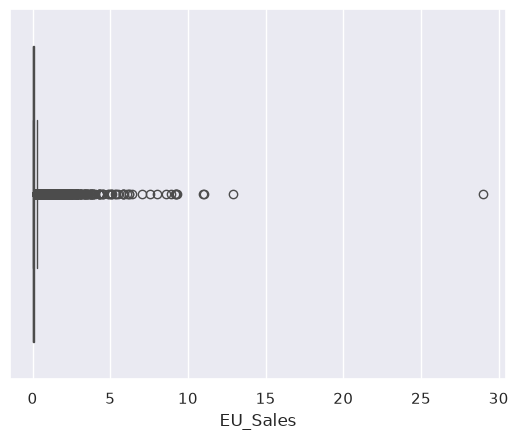

In [16]:
sns.boxplot(x=vgame_df['EU_Sales'])

<Axes: xlabel='JP_Sales'>

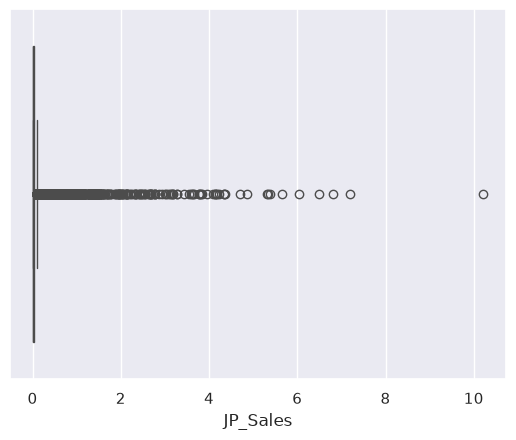

In [17]:
sns.boxplot(x=vgame_df['JP_Sales'])

<Axes: xlabel='Other_Sales'>

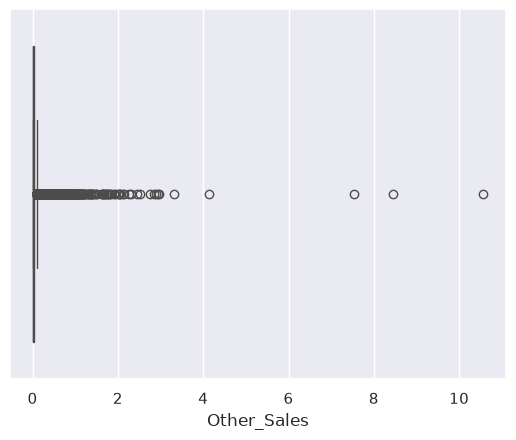

In [18]:
sns.boxplot(x=vgame_df['Other_Sales'])

<Axes: xlabel='Global_Sales'>

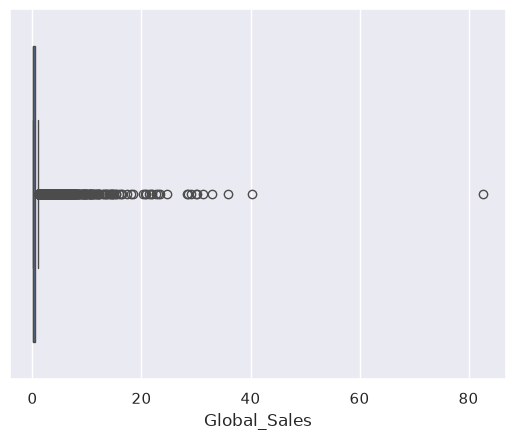

In [19]:
sns.boxplot(x=vgame_df['Global_Sales'])

Outliers have been identified across regional sales columns. IQR-based removal keeps analysis focused on the majority of games.

In [20]:
numeric_cols = vgame_df.select_dtypes(include='number').columns
Q1 = vgame_df[numeric_cols].quantile(0.25)
Q3 = vgame_df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

In [21]:
mask = ~((vgame_df[numeric_cols] < (Q1 - 1.5 * IQR)) | (vgame_df[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)
vgame_df = vgame_df[mask]
vgame_df.shape

(11675, 9)

Approximately 1,600 rows were flagged as outliers and removed, leaving a cleaner distribution for correlation and regional comparison analysis.

## 9. Plot different features against one another (scatter), against frequency (histogram)

Histogram shows the frequency distribution of North American sales. Most games fall in a low-sales range, with a small number of titles achieving outsized NA_Sales figures — a right-skewed distribution typical of entertainment markets.

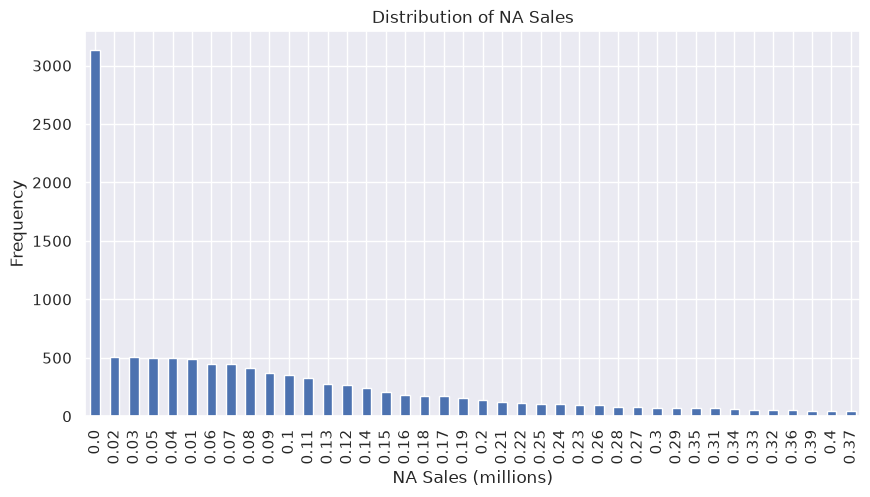

In [22]:
# prompt: create a histogram

vgame_df['NA_Sales'].value_counts().nlargest(40).plot(kind='bar', figsize=(10,5))
plt.title('Distribution of NA Sales')
plt.ylabel('Frequency')
plt.xlabel('NA Sales (millions)');

The heatmap reveals correlations between regional sales figures. North America and Europe tend to move together, while Japan shows weaker correlation with Western markets — reflecting distinct gaming preferences and franchises dominant in each region.

In [23]:
# prompt: create heatmap

plt.figure(figsize=(10,5))
c= vgame_df.corr()
sns.heatmap(c,cmap="BrBG",annot=True)
c

ValueError: could not convert string to float: 'Action'

<Figure size 1000x500 with 0 Axes>

The scatter plot compares Global Sales to North American Sales. The strong positive relationship confirms that NA performance is a significant driver of global totals — games that succeed in North America tend to succeed globally.

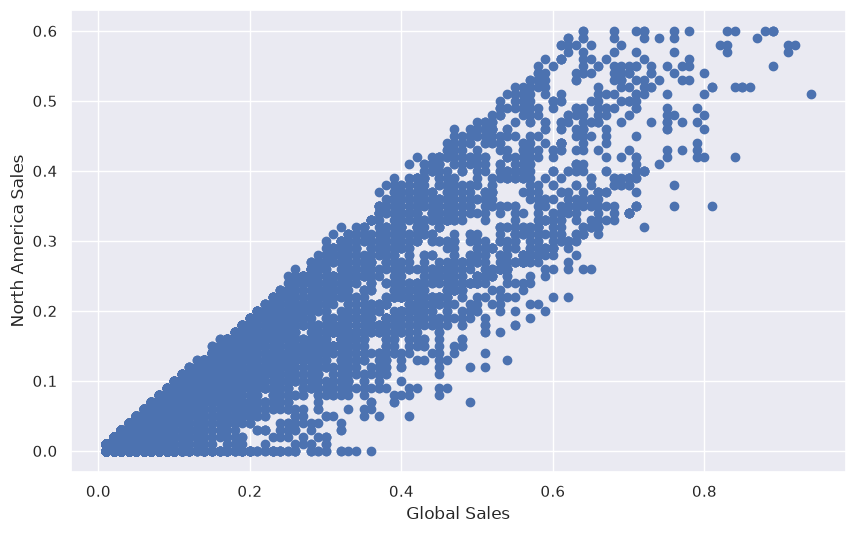

In [24]:
# prompt: create a scatter plot

fig, ax = plt.subplots(figsize=(10,6))
ax.scatter(vgame_df['Global_Sales'], vgame_df['NA_Sales'])
ax.set_xlabel('Global Sales')
ax.set_ylabel('North America Sales')
plt.show()


Hence the above are some of the steps involved in Exploratory data analysis, these are some general steps that you must follow in order to perform EDA. There are many more yet to come but for now, this is more than enough idea as to how to perform a good EDA given any data sets.

**Stay tuned for more updates.**

## Thank you.

##Genre Analysis

In [25]:
# Sales by Genre
genre_sales = vgame_df.groupby('Genre')[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Global_Sales']].sum()
genre_sales = genre_sales.sort_values('Global_Sales', ascending=False)
print(genre_sales.head(10).to_string())

              NA_Sales  EU_Sales  JP_Sales  Global_Sales
Genre                                                   
Action          252.92    116.98     23.77        431.71
Sports          211.66     72.15      9.48        318.87
Misc            136.97     47.11     13.19        214.84
Shooter         100.47     52.05      4.42        172.54
Racing           96.56     46.67      2.50        159.10
Platform         74.49     30.60      2.97        116.52
Role-Playing     56.01     26.24     22.35        113.85
Simulation       68.23     19.93      5.28        101.47
Adventure        49.82     24.02     19.97        100.99
Fighting         56.56     22.82     10.50         97.03


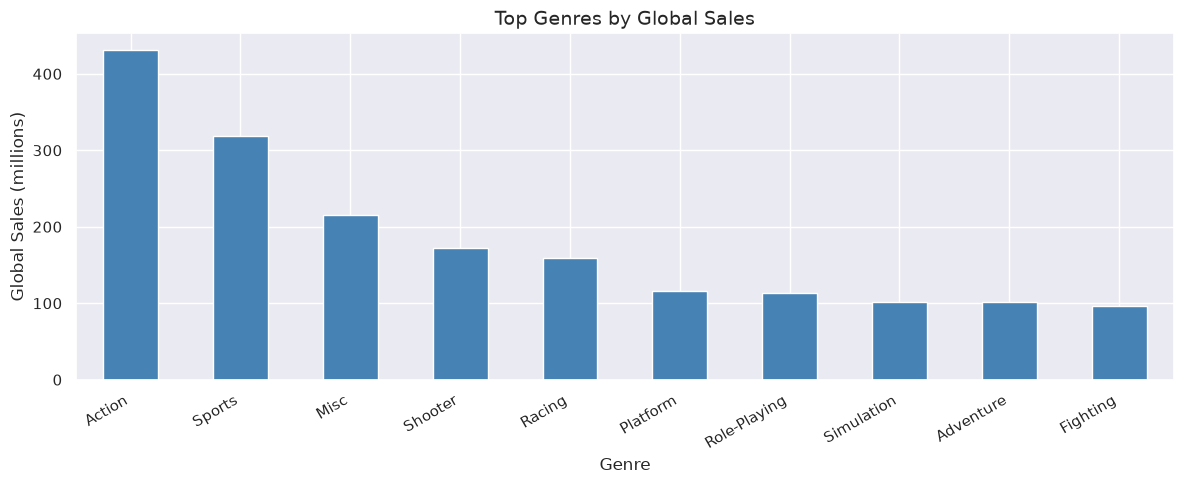

In [26]:
genre_sales['Global_Sales'].sort_values(ascending=False).head(10).plot(
    kind='bar', figsize=(12, 5), color='steelblue')
plt.title('Top Genres by Global Sales', fontsize=14)
plt.xlabel('Genre')
plt.ylabel('Global Sales (millions)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

##Regional Sales Comparison

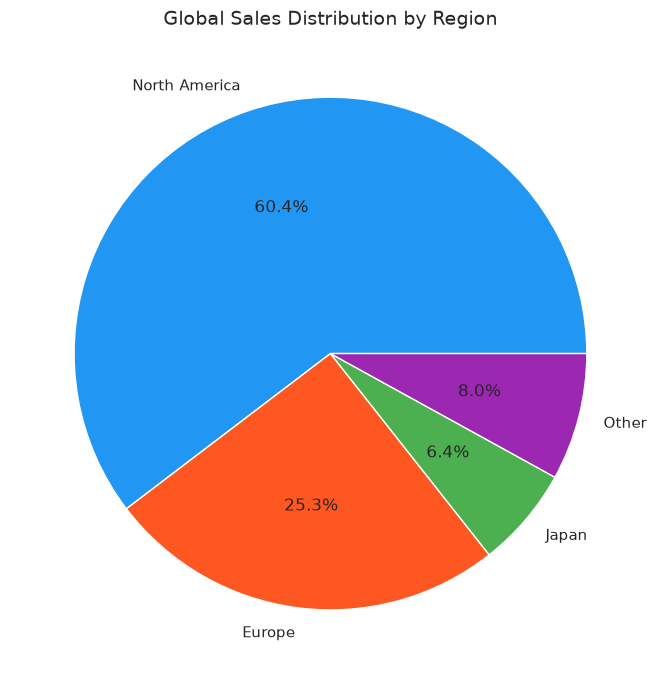

In [27]:
region_totals = vgame_df[['NA_Sales','EU_Sales','JP_Sales','Other_Sales']].sum()
region_totals.index = ['North America', 'Europe', 'Japan', 'Other']

region_totals.plot(kind='pie', figsize=(7, 7), autopct='%1.1f%%',
                   colors=['#2196F3','#FF5722','#4CAF50','#9C27B0'])
plt.title('Global Sales Distribution by Region', fontsize=14)
plt.ylabel('')
plt.tight_layout()
plt.show()

#Summary

##Key Findings

- **11,914 titles** analyzed after removing 989 duplicates and ~1,600 outlier rows
- **North America** is the dominant regional market, accounting for the largest share of global sales
- **Action and Sports** genres top global sales by a wide margin; Puzzle and Strategy lag
- Strong positive correlation between NA_Sales and Global_Sales — NA performance is the strongest regional predictor of global success
- Japan's gaming market shows distinct preferences, with weaker correlation to NA and EU sales

##Conclusion

Regional sales data confirms that North America is the anchor market for global video game performance. Genres that perform well in NA — particularly Action, Sports, and Shooters — tend to translate into strong global totals. Japan's independent preferences present a unique market dynamic worth targeting separately.
